# Telecom Customer Churn Prediction
- Predict which telecom customers are likely to stop using the company's services.
- Explain the main churn risk factors and suggest potential retention actions.

## Data Preprocessing
Check duplicates, missing values and data types, then prepare the churn target.

In [4]:
# all imports
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import math

from sklearn.model_selection import train_test_split

In [5]:
# load the dataset
# data was taken from url = https://www.kaggle.com/datasets/blastchar/telco-customer-churn
df = pd.read_csv("telecom_users.csv")

print("Dataset shape:", df.shape)
display(df.head())
df.info()

Dataset shape: (5986, 22)


,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1869,7010-BRBUU,Male,0,Yes,Yes,72,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.10,1734.65,No
1,4528,9688-YGXVR,Female,0,No,No,44,Yes,No,Fiber optic,...,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),88.15,3973.2,No
2,6344,9286-DOJGF,Female,1,Yes,No,38,Yes,Yes,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),74.95,2869.85,Yes
3,6739,6994-KERXL,Male,0,No,No,4,Yes,No,DSL,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,55.90,238.5,No
4,432,2181-UAESM,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,Month-to-month,No,Electronic check,53.45,119.5,No


<class 'pandas.DataFrame'>
RangeIndex: 5986 entries, 0 to 5985
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        5986 non-null   int64  
 1   customerID        5986 non-null   str    
 2   gender            5986 non-null   str    
 3   SeniorCitizen     5986 non-null   int64  
 4   Partner           5986 non-null   str    
 5   Dependents        5986 non-null   str    
 6   tenure            5986 non-null   int64  
 7   PhoneService      5986 non-null   str    
 8   MultipleLines     5986 non-null   str    
 9   InternetService   5986 non-null   str    
 10  OnlineSecurity    5986 non-null   str    
 11  OnlineBackup      5986 non-null   str    
 12  DeviceProtection  5986 non-null   str    
 13  TechSupport       5986 non-null   str    
 14  StreamingTV       5986 non-null   str    
 15  StreamingMovies   5986 non-null   str    
 16  Contract          5986 non-null   str    
 17  Paperl

In [6]:
# first check the unnamed column - Inspect the possible saved index
display(df[["Unnamed: 0", "customerID"]].head())

,Unnamed: 0,customerID
0,1869,7010-BRBUU
1,4528,9688-YGXVR
2,6344,9286-DOJGF
3,6739,6994-KERXL
4,432,2181-UAESM


In [7]:
# unnamed seems like important. so removing it
df = df.drop(columns=["Unnamed: 0"])

print("Dataset shape:", df.shape)

Dataset shape: (5986, 21)


In [8]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [9]:
# lets look at the unique values in each column
col_count = 0
for col in df.columns:
    if df[col].nunique(dropna=False) > 100:
        print(f"\n")
        print(f"{col}: Can not display, since it has more than 100 unique values")
    if df[col].nunique(dropna=False) <= 100:
        print(f"\n{col}:")
        print(df[col].unique().tolist())
        col_count += 1

print("columns displyed: ", col_count)



customerID: Can not display, since it has more than 100 unique values

gender:
['Male', 'Female']

SeniorCitizen:
[0, 1]

Partner:
['Yes', 'No']

Dependents:
['Yes', 'No']

tenure:
[72, 44, 38, 4, 2, 70, 33, 1, 39, 55, 52, 30, 60, 50, 32, 51, 69, 42, 14, 62, 5, 63, 67, 40, 65, 16, 46, 11, 49, 68, 10, 53, 54, 15, 3, 71, 8, 64, 57, 20, 26, 31, 7, 35, 6, 13, 23, 9, 45, 17, 34, 58, 12, 25, 28, 29, 43, 19, 41, 37, 27, 22, 24, 18, 56, 66, 59, 48, 47, 61, 21, 0, 36]

PhoneService:
['Yes', 'No']

MultipleLines:
['Yes', 'No', 'No phone service']

InternetService:
['No', 'Fiber optic', 'DSL']

OnlineSecurity:
['No internet service', 'No', 'Yes']

OnlineBackup:
['No internet service', 'Yes', 'No']

DeviceProtection:
['No internet service', 'Yes', 'No']

TechSupport:
['No internet service', 'No', 'Yes']

StreamingTV:
['No internet service', 'Yes', 'No']

StreamingMovies:
['No internet service', 'No', 'Yes']

Contract:
['Two year', 'Month-to-month', 'One year']

PaperlessBilling:
['No', 'Yes']

P

## Understanding the Columns

- **customerID:** Unique customer identifier.
- **gender:** Customer's gender: Male or Female.
- **SeniorCitizen:** Senior-citizen status: 1 = Yes, 0 = No; not necessarily retired.
- **Partner:** Whether the customer has a partner.
- **Dependents:** Whether the customer has dependents.
- **tenure:** Number of months the customer has stayed with the company.
- **PhoneService:** Whether the customer has phone service.
- **MultipleLines:** Whether the customer has multiple phone lines.
- **InternetService:** Internet type: DSL, Fiber optic or No.
- **OnlineSecurity:** Whether the customer has online security.
- **OnlineBackup:** Whether the customer has online backup.
- **DeviceProtection:** Whether the customer has device protection.
- **TechSupport:** Whether the customer has technical support.
- **StreamingTV:** Whether the customer has streaming TV.
- **StreamingMovies:** Whether the customer has streaming movies.
- **Contract:** Month-to-month, One year or Two year.
- **PaperlessBilling:** Whether the customer receives paperless bills.
- **PaymentMethod:** How the customer pays their bills.
- **MonthlyCharges:** Amount charged per month.
- **TotalCharges:** Total amount charged during the customer's time with the company.
- **Churn:** Target variable: Yes = customer left, No = customer stayed.

“No internet service” or “No phone service” means the underlying service is absent.

In [10]:
# check duplicates
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())

Duplicate rows: 0
Duplicate customer IDs: 0


In [15]:
# check missing values
# Missing values recognised by pandas
print("Missing values:")
print(df.isna().sum())

# Empty strings or spaces in text columns - since most columns are strings(object)
print("\nBlank text values:")
for col in df.select_dtypes(include=["object", "string"]).columns:
    count = df[col].str.strip().eq("").sum()
    if count > 0:
        print(f"{col}: {count}")

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Blank text values:
TotalCharges: 10


**Total Charges** - have 10 blank values
since total and monthly chnages are of object type - lets convert it to numerical value. 

In [16]:
# lets see which 10 values were blank
blank_total = df["TotalCharges"].str.strip().eq("")

display(
    df.loc[
        blank_total,
        ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"] # adding tenure to understand why they were blank
    ]
)

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
356,2775-SEFEE,0,61.90,,No
634,1371-DWPAZ,0,56.05,,No
2771,3213-VVOLG,0,25.35,,No
3086,2923-ARZLG,0,19.70,,No
3255,7644-OMVMY,0,19.85,,No
4326,5709-LVOEQ,0,80.85,,No
5375,3115-CZMZD,0,20.25,,No
5382,2520-SGTTA,0,20.00,,No
5695,4472-LVYGI,0,52.55,,No
5951,4367-NUYAO,0,25.75,,No


Looks like they are new coustomers as the tenure = 0, so total charges are missing!

In [17]:
# lets convert total charges to numerical category
df["MonthlyCharges"] = pd.to_numeric(df["MonthlyCharges"], errors="raise") # already numerical
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce") # coerce - converts empty to NaN

display(df[["MonthlyCharges", "TotalCharges"]].dtypes)
display(df[["MonthlyCharges", "TotalCharges"]].isna().sum())

MonthlyCharges    float64
TotalCharges      float64
dtype: object

MonthlyCharges     0
TotalCharges      10
dtype: int64

In [18]:
# instead of NaN - since they are new customers- i will convert Nan to zeros
mask = df["TotalCharges"].isna() & df["tenure"].eq(0)
df.loc[mask, "TotalCharges"] = 0

print("Missing TotalCharges:", df["TotalCharges"].isna().sum())

Missing TotalCharges: 0


In [19]:
# lets see how many customers churned versus stayed. - is the target column balanced?
churn_summary = pd.DataFrame({
    "Count": df["Churn"].value_counts(),
    "Percentage": df["Churn"].value_counts(normalize=True).mul(100).round(2)
})

display(churn_summary)

,Count,Percentage
Churn,,
No,4399,73.49
Yes,1587,26.51


**churn** - our target feature is imbalanced!!
- 73% Stayed
- 26% Left / Churned
- Predicting 'No' for everyone would achieve 73.49% accuracy while missing every churner
- so we have to evaluate precision, recall and F1.

## visualize the features

In [24]:
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"] # removing senior citizen (numerical category)- it has 1 or 0

sns.pairplot(
    data=df,
    vars=numeric_features,
    hue="Churn",
    diag_kind="hist",
    plot_kws={"alpha": 0.3, "s": 12}
)

plt.show()

RecursionError: maximum recursion depth exceeded

Error in callback <function _draw_all_if_interactive at 0x000001C8B86EB1C0> (for post_execute), with arguments args (),kwargs {}:


RecursionError: maximum recursion depth exceeded

RecursionError: maximum recursion depth exceeded

<Figure size 750x750 with 9 Axes>

***
Blue = stayed and orange = churned
**initial observations from numerical features**

- Tenure: orange points are concentrated at shorter tenures. Churn appears less common among long-term customers.
- MonthlyCharges: churners appear concentrated around higher monthly charges, roughly 70–110.
- TotalCharges: many churners have low total charges, which may reflect their shorter tenure.
Tenure and TotalCharges: total charges generally increase with tenure, as expected.

***

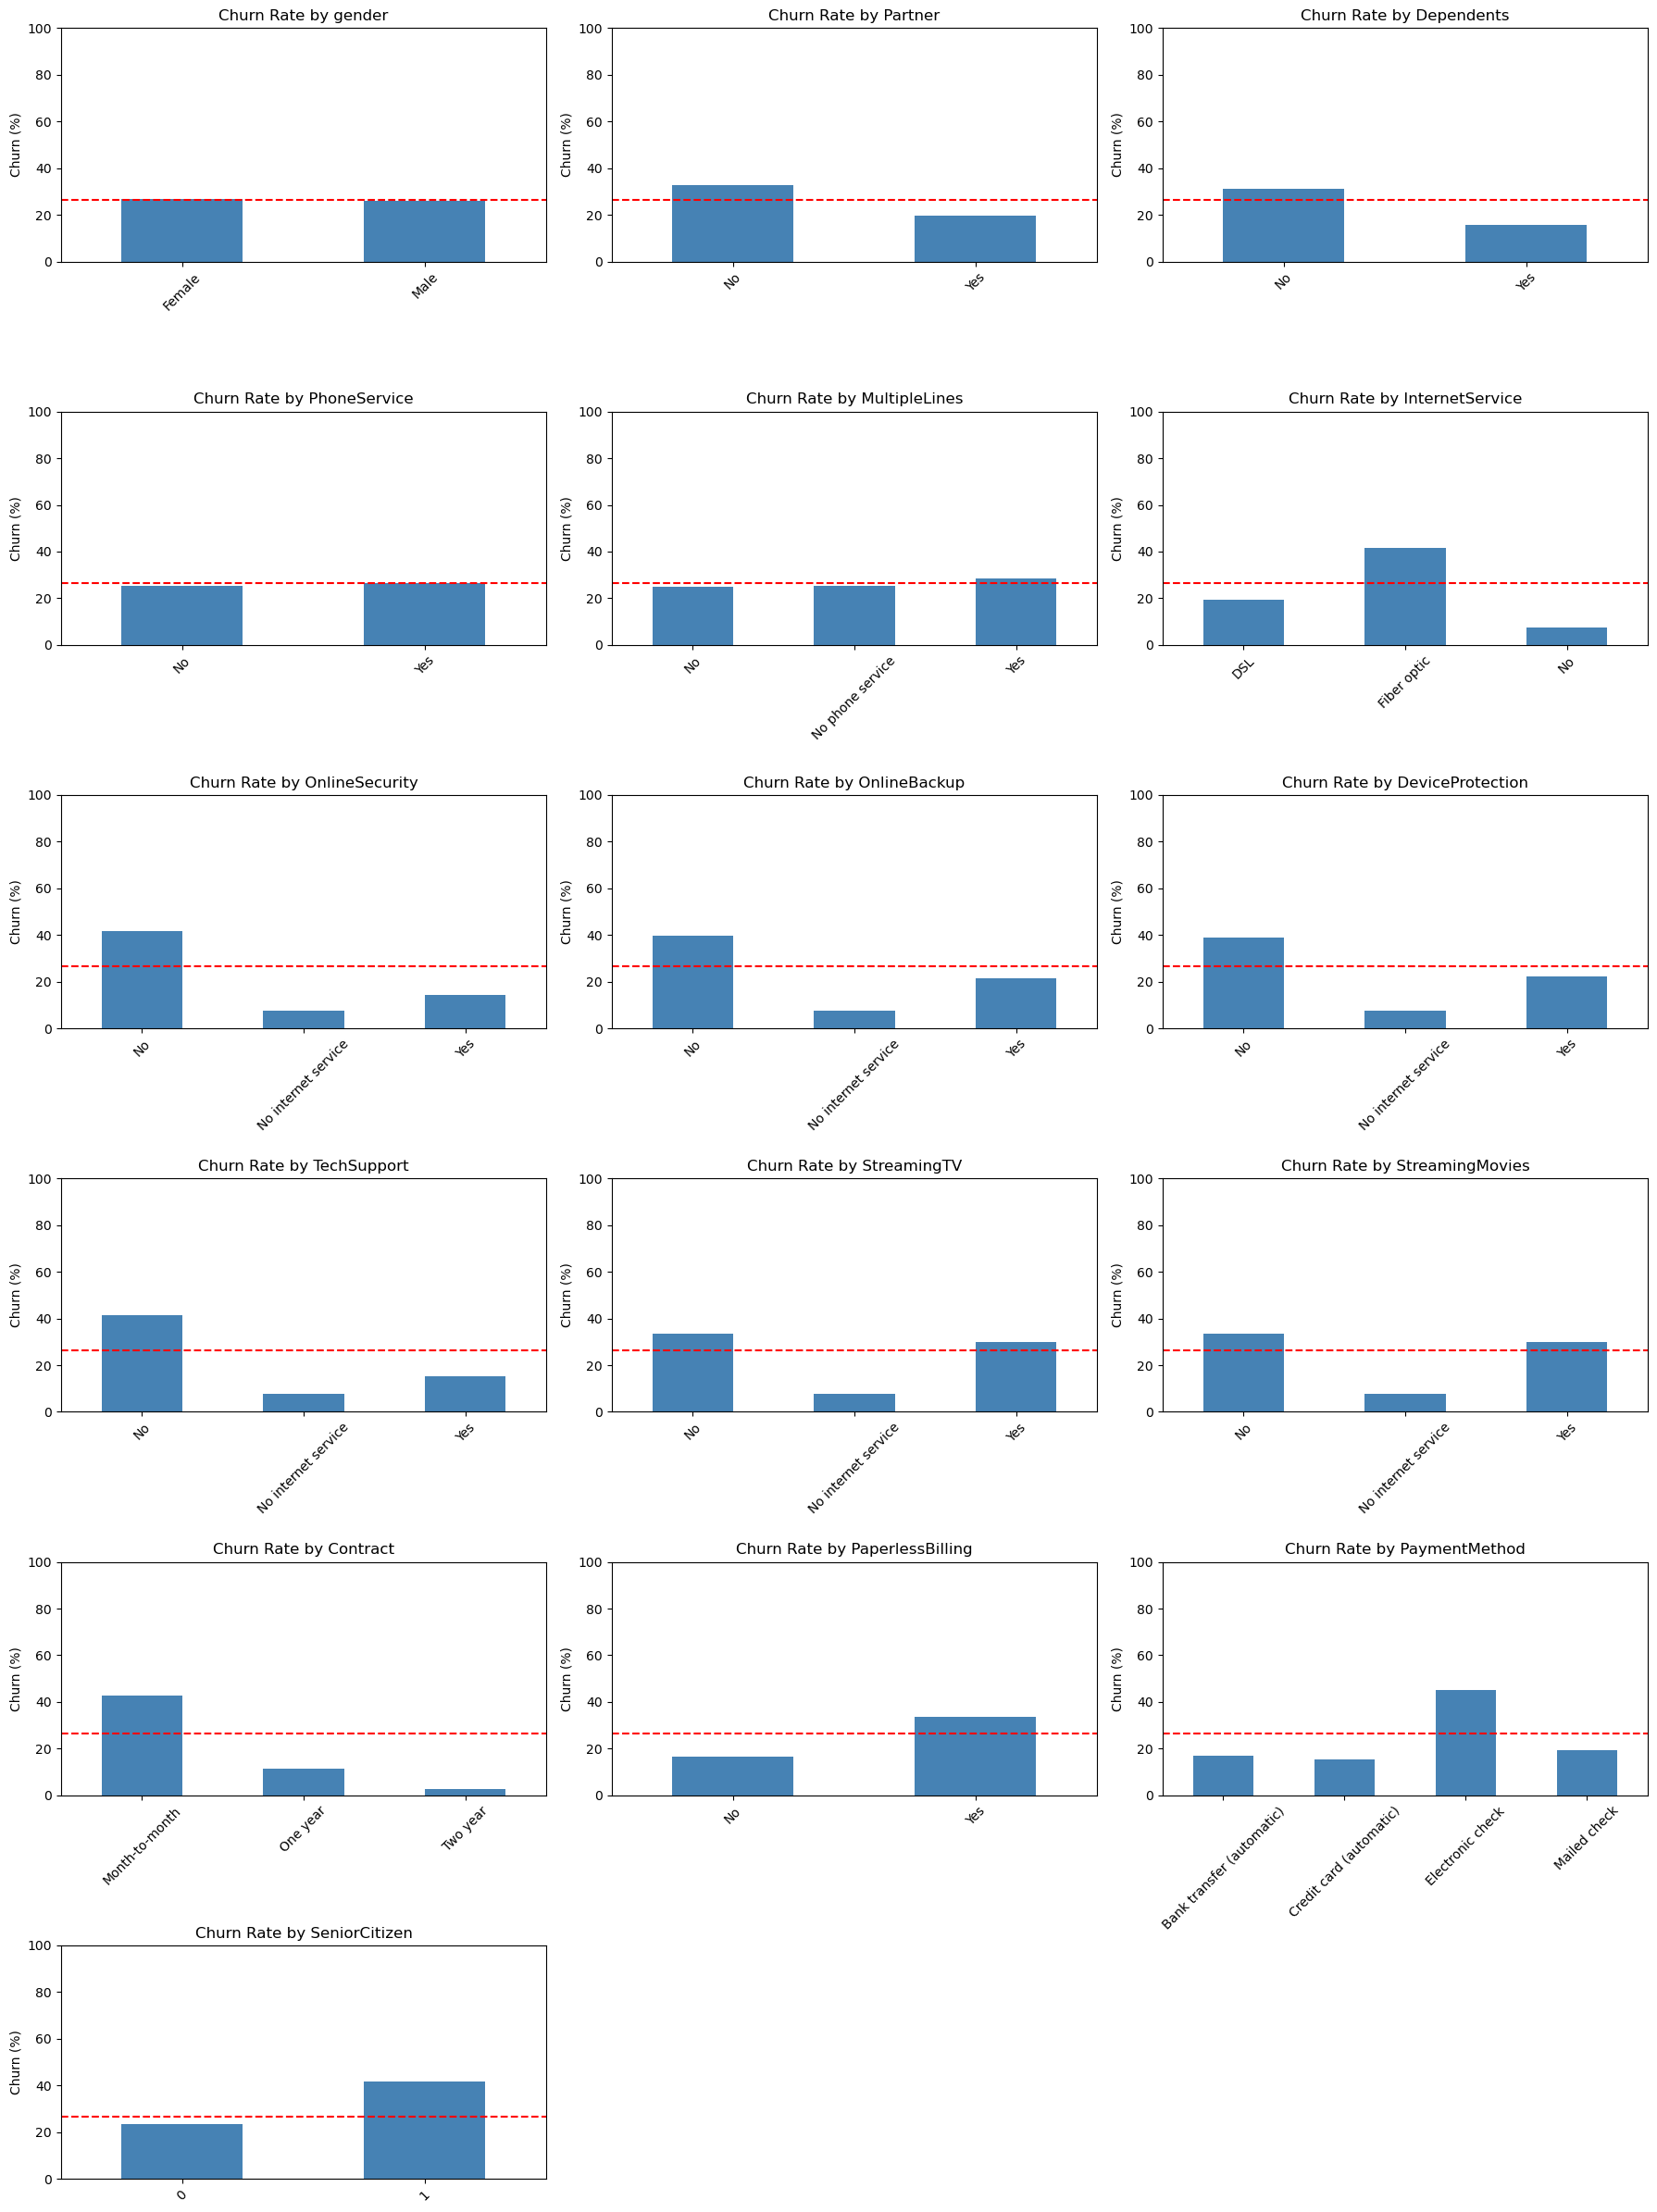

In [25]:
# lets comparre categorical features
categorical_features = [col for col in df.select_dtypes(include="object").columns
    if col not in ["customerID", "Churn"] # don't want customer id and churn
] + ["SeniorCitizen"] #adding senior citizen to category

ncols = 3
nrows = math.ceil(len(categorical_features) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for ax, col in zip(axes, categorical_features):
    churn_rate = (
        df.groupby(col)["Churn"]
        .apply(lambda values: values.eq("Yes").mean())
        .mul(100)
    )

    churn_rate.plot.bar(ax=ax, color="steelblue")
    ax.axhline(
        df["Churn"].eq("Yes").mean() * 100,
        color="red", linestyle="--"
    )
    ax.set_title(f"Churn Rate by {col}")
    ax.set_ylabel("Churn (%)")
    ax.set_xlabel("")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=45)

for ax in axes[len(categorical_features):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

***
A high churn rate means a larger percentage of customers in that group left the company.

**Observations from Categorical Features**

1. Gender: Male and female customers have similar churn rates.
2. Partner: Customers without a partner have higher churn.
3. Dependents: Customers without dependents have higher churn.
4. PhoneService: Customers with and without phone service have similar churn rates.
5. MultipleLines: Customers with multiple lines have slightly higher churn.
6. InternetService: Fiber-optic customers have the highest churn; customers without internet have the lowest.
7. OnlineSecurity: Customers without online security have higher churn than those with it.
8. OnlineBackup: Customers without online backup have higher churn than those with it.
9. DeviceProtection: Customers without device protection have higher churn than those with it.
10. TechSupport: Customers without technical support have higher churn than those with it.
11. StreamingTV: Among internet customers, those without streaming TV have slightly higher churn.
12. StreamingMovies: Among internet customers, those without streaming movies have slightly higher churn.
13. Contract: Month-to-month customers have the highest churn; two-year customers have the lowest.
14. PaperlessBilling: Customers using paperless billing have higher churn.
15. PaymentMethod: Electronic-check users have the highest churn.
16. SeniorCitizen: Senior citizens have higher churn than non-senior customers.

***

## Data Modelling

In [ ]:
# Features: exclude the ID and target
X = df.drop(columns=["customerID", "Churn"])

# Target: 1 = churn, 0 = stayed
y = df["Churn"].map({"No": 0, "Yes": 1})

# 80% training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y # split churn equally
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTraining churn percentages:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTest churn percentages:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Training shape: (4788, 19)
Test shape: (1198, 19)

Training churn percentages:
Churn
0    73.5
1    26.5
Name: proportion, dtype: float64

Test churn percentages:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


***
*let's keep the test set aside until we’ve selected the model, hyperparameters and decision threshold.*
*evaluate models using cross-validtaion - Encoding and scaling will also be fitted inside each cross-validation training fold, using a pipeline*
- Training set + cross-validation: compare models, tune parameters and choose the threshold.
-Test set: evaluate the chosen model once to estimate performance on unseen customers.

After seeing the test results, we shouldn’t keep adjusting the model to improve that score—that would make the test set part of model selection.
***

# Consolidated Results and Churn Prediction

## Project objective
Use customer account and service attributes to identify customers who may churn, understand the patterns associated with churn, and support retention planning.

## Exploratory findings
The exploratory analysis in this notebook reports these patterns:
- Churn is more common among customers with shorter tenure.
- Month-to-month contracts show higher churn than longer contracts.
- Fiber-optic customers show comparatively high churn.
- Customers without technical support or online security show higher churn.
- Electronic-check users show comparatively high churn.
- Gender and phone-service status show relatively limited differences in the notebook's analysis.

These are associations in the dataset, not proof of causation. The predictive model below is needed to assess whether the patterns generalize to unseen customers.

## Data preparation notes
The notebook reports 5,986 customer records, no duplicate customer IDs, and 10 blank `TotalCharges` values associated with zero-tenure customers. The modeling section handles those blank values as zero and excludes customer IDs from the predictors.


In [ ]:
# Modeling pipeline: compare Logistic Regression, Random Forest, and Gradient Boosting
# This cell assumes the cleaned dataframe is named df and includes the target column Churn.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    RocCurveDisplay, precision_recall_curve, average_precision_score
)
from sklearn.inspection import permutation_importance

# Normalize target and TotalCharges if needed
model_df = df.copy()
model_df["TotalCharges"] = pd.to_numeric(model_df["TotalCharges"], errors="coerce")
model_df["TotalCharges"] = model_df["TotalCharges"].fillna(0)

if model_df["Churn"].dtype == "object":
    model_df["Churn"] = model_df["Churn"].map({"Yes": 1, "No": 0})

model_df = model_df.dropna(subset=["Churn"])
X = model_df.drop(columns=[c for c in ["Churn", "customerID", "Unnamed: 0"] if c in model_df.columns])
y = model_df["Churn"].astype(int)

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, min_samples_leaf=2,
        class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=150, learning_rate=0.08, random_state=42
    )
}

fitted_models = {}
rows = []

for name, estimator in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", estimator)])
    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe
    prob = pipe.predict_proba(X_test)[:, 1]
    pred = (prob >= 0.50).astype(int)
    rows.append({
        "Model": name,
        "ROC-AUC": roc_auc_score(y_test, prob),
        "PR-AUC": average_precision_score(y_test, prob),
        "Precision": classification_report(
            y_test, pred, output_dict=True, zero_division=0
        )["1"]["precision"],
        "Recall": classification_report(
            y_test, pred, output_dict=True, zero_division=0
        )["1"]["recall"],
        "F1": classification_report(
            y_test, pred, output_dict=True, zero_division=0
        )["1"]["f1-score"]
    })

comparison = pd.DataFrame(rows).sort_values("ROC-AUC", ascending=False)
display(comparison.round(3))


In [ ]:
# Evaluate the model with the highest ROC-AUC on the held-out test set
best_name = comparison.iloc[0]["Model"]
best_model = fitted_models[best_name]

test_prob = best_model.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= 0.50).astype(int)

print("Selected model:", best_name)
print("\nClassification report at threshold 0.50:")
print(classification_report(y_test, test_pred, target_names=["No churn", "Churn"], zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_test, test_pred))
print("ROC-AUC:", round(roc_auc_score(y_test, test_prob), 3))
print("PR-AUC:", round(average_precision_score(y_test, test_prob), 3))

RocCurveDisplay.from_predictions(y_test, test_prob)
plt.title(f"ROC Curve — {best_name}")
plt.show()

precision, recall, thresholds = precision_recall_curve(y_test, test_prob)
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Probability threshold")
plt.ylabel("Score")
plt.title(f"Precision and Recall by Threshold — {best_name}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
# Permutation importance on the original input features
perm = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=10, random_state=42,
    scoring="roc_auc", n_jobs=-1
)
importance = pd.Series(
    perm.importances_mean, index=X_test.columns
).sort_values(ascending=True)

display(importance.sort_values(ascending=False).rename("Mean ROC-AUC decrease").to_frame())

importance.plot(kind="barh", figsize=(9, 6))
plt.title(f"Permutation Feature Importance — {best_name}")
plt.xlabel("Mean decrease in ROC-AUC after shuffling")
plt.tight_layout()
plt.show()


In [ ]:
# Rank held-out customers by estimated churn risk
customer_results = X_test.copy()
customer_results["ActualChurn"] = y_test
customer_results["ChurnProbability"] = test_prob
customer_results["PredictedChurn_50pct"] = test_pred
customer_results = customer_results.sort_values("ChurnProbability", ascending=False)

display(customer_results.head(20))
customer_results.to_csv("churn_predictions_test_set.csv", index=True)
print("Saved predictions to churn_predictions_test_set.csv")


## Interpretation and business use

- Use **recall** to understand how many customers who churned were identified.
- Use **precision** to understand how many flagged customers actually churned.
- Use **ROC-AUC** and **PR-AUC** to compare models across thresholds. PR-AUC is especially useful when the churn class is less frequent.
- Review the confusion matrix and choose a probability threshold based on retention-team capacity and the relative costs of missed churners and unnecessary outreach.
- Treat permutation importance as predictive importance, not causal impact. Correlated features can share or mask importance.
- The predictions in this notebook are for the held-out test set, whose churn outcomes are already known for evaluation. For operational predictions, apply the fitted model to a separate, current customer file with no churn labels.

## Final conclusion
The exploratory results point to tenure, contract type, internet service, support/security add-ons, and payment method as useful areas to investigate. The modeling cells above complete the next analytical stage by comparing classifiers, evaluating test-set performance, interpreting feature importance, and producing a ranked test-set prediction file. Actual model scores and top-risk customer records will appear after the notebook is run with the dataset available.
